✅ Načítaných 1,251 riadkov zo súboru recordings/rc_e0976bc8.jsonl.gz

📊 Počet správ podľa typu (kind):
  sample          : 1251

⏱  Časový rozsah: 4.98 sekúnd
⏰  Od: 2025-10-17 17:05:19.990820  Do: 2025-10-17 17:05:24.970299

🧩 Počet 'sample' správ: 1251
   - priemerný počet ADC hodnôt: 6.00
   - priemerná IMU teplota: 44.00 °C


Matplotlib is building the font cache; this may take a moment.


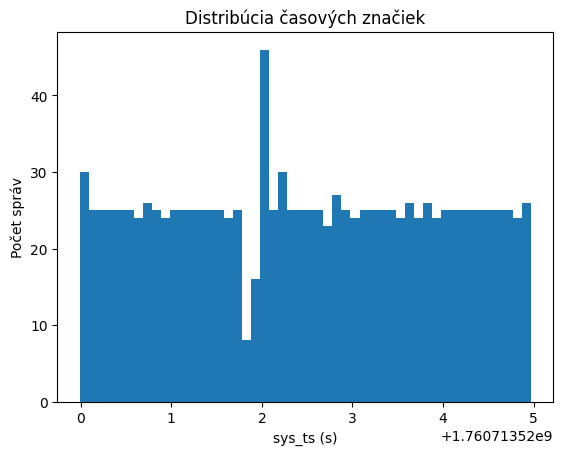

In [ ]:
import gzip
import json
from collections import Counter
import pandas as pd
from datetime import datetime

# === cesta k nahrávke ===
# zmeň podľa svojho súboru (môže byť .jsonl alebo .jsonl.gz)
path = "recordings/rc_e0976bc8.jsonl.gz"

# === načítanie všetkých riadkov ===
records = []
open_func = gzip.open if path.endswith(".gz") else open

with open_func(path, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            records.append(obj)
        except Exception as e:
            print("⚠️ JSON decode error:", e)
            continue

print(f" Načítaných {len(records):,} riadkov zo súboru {path}")

# === rýchla analýza ===
if not records:
    raise ValueError("Žiadne dáta sa nenačítali – skontroluj cestu alebo formát.")

# typy správ (kind)
kind_counts = Counter(r.get("kind", "unknown") for r in records)
print("\n📊 Počet správ podľa typu (kind):")
for k, v in kind_counts.items():
    print(f"  {k:15s} : {v}")

# časové značky (ak existujú)
ts = [r.get("sys_ts") or r.get("ts") for r in records if isinstance(r.get("sys_ts") or r.get("ts"), (int, float))]
if len(ts) > 1:
    duration = max(ts) - min(ts)
    print(f"\n⏱  Časový rozsah: {duration:.2f} sekúnd")
    print(f"⏰  Od: {datetime.fromtimestamp(min(ts))}  Do: {datetime.fromtimestamp(max(ts))}")
else:
    print("\n⚠️  Nedostatok časových značiek pre výpočet trvania.")

# === 4️⃣ voliteľná mini-analýza ADC a IMU ===
sample_msgs = [r for r in records if r.get("kind") == "sample"]

if sample_msgs:
    adc_lens = [len(r.get("adc", [])) for r in sample_msgs]
    imu_temps = [r.get("imu", {}).get("temp") for r in sample_msgs if r.get("imu")]
    print(f"\n🧩 Počet 'sample' správ: {len(sample_msgs)}")
    print(f"   - priemerný počet ADC hodnôt: {sum(adc_lens)/len(adc_lens):.2f}")
    if imu_temps:
        print(f"   - priemerná IMU teplota: {sum(imu_temps)/len(imu_temps):.2f} °C")
else:
    print("\n⚠️  Žiadne 'sample' správy – nahrávka mohla obsahovať iba udalosti (napr. haptic/reboot).")

# === voliteľne rýchla vizualizácia (ak máš matplotlib) ===
try:
    import matplotlib.pyplot as plt
    plt.hist([r.get("sys_ts") for r in records if r.get("sys_ts")], bins=50)
    plt.xlabel("sys_ts (s)")
    plt.ylabel("Počet správ")
    plt.title("Distribúcia časových značiek")
    plt.show()
except Exception as e:
    print("(vizualizácia preskočená, matplotlib nebol dostupný)")

In [2]:
records

[{'kind': 'sample',
  'port': '/dev/cu.usbserial-120',
  'ts': 1760713519.9907079,
  'sys_ts': 1760713519.9908202,
  'sys_mono': 1166086.3057055,
  'type': 1,
  'adc': [0.0, -2.3203125, -36.375, -9.15625, 12.3203125, 18.5078125],
  'imu': {'linAccX': 0.01,
   'linAccY': -0.04,
   'linAccZ': 0.0,
   'pitch': -59.8125,
   'roll': 2.4375,
   'yaw': 343.3125,
   'gyroX': 0.0,
   'gyroY': -0.0625,
   'gyroZ': 0.0625,
   'gravX': 0.42,
   'gravY': 8.46,
   'gravZ': 4.92,
   'magX': -36.25,
   'magY': -26.75,
   'magZ': -28.0625,
   'quatW': 0.8575439453125,
   'quatX': 0.49664306640625,
   'quatY': 0.0472412109375,
   'quatZ': 0.12548828125,
   'temp': 44.0},
  'uid': 6160478,
  'uid_hex': '0x005E005E',
  'uid_dec': 6160478,
  'fw': 231,
  'hand': 'left',
  'hand_code': 1},
 {'kind': 'sample',
  'port': '/dev/cu.usbserial-120',
  'ts': 1760713519.9907079,
  'sys_ts': 1760713519.9908748,
  'sys_mono': 1166086.30576075,
  'type': 1,
  'adc': [0.0, 45.671875, -50.0859375, -6.5625, 22.15625, -17